# RQ2: Which bowlers demonstrate the highest wicket-taking probability per delivery?

**Research Question:** Which bowlers demonstrate the highest wicket-taking probability per delivery, and how do over-phase effects (powerplay, middle, death) influence wicket likelihood?

**Approach:** Exploratory analysis + Random Forest with bowler-level feature importance

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('tables', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [4]:
df = pd.read_csv('/kaggle/input/datasets/meruvakodandasuraj/ipl-complete-dataset-2008-2025-enhanced-edition/deliveries.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (134190, 18)


,delivery_id,match_id,innings,over,ball,batting_team,bowling_team,striker,non_striker,bowler,batsman_runs,extra_runs,total_runs,extra_type,is_wicket,dismissal_type,dismissed_player,fielder
0,D0000001,M0001,1,1,1,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,2,0,2,NaN,False,NaN,NaN,NaN
1,D0000002,M0001,1,1,2,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,4,0,4,NaN,False,NaN,NaN,NaN
2,D0000003,M0001,1,1,3,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,0,0,0,NaN,True,caught,Yuzvendra Kumar,Aiden Anderson


In [5]:
# ── Over Phase ──
def over_phase(o):
    if o <= 6: return 'Powerplay'
    elif o <= 15: return 'Middle'
    else: return 'Death'

df['over_phase'] = df['over'].apply(over_phase)
df['is_wicket_int'] = df['is_wicket'].astype(int)

In [6]:
# ── Bowler Wicket Stats ──
bowler_stats = df.groupby('bowler').agg(
    deliveries=('delivery_id', 'count'),
    wickets=('is_wicket_int', 'sum')
).reset_index()
bowler_stats['wicket_rate'] = bowler_stats['wickets'] / bowler_stats['deliveries']

# Filter: min 50 deliveries for reliability
bowler_stats = bowler_stats[bowler_stats['deliveries'] >= 50].sort_values('wicket_rate', ascending=False)
top15 = bowler_stats.head(15).reset_index(drop=True)

print('Top 15 bowlers by wicket rate:')
print(top15[['bowler', 'deliveries', 'wickets', 'wicket_rate']].to_string(index=False))
top15.to_csv('tables/Table_2_1_top_bowlers_wicket_rate.csv', index=False)
print('\nTable 2.1 saved.')

Top 15 bowlers by wicket rate:
               bowler  deliveries  wickets  wicket_rate
Najibullah Williamson         192       21     0.109375
          Umesh Shami         173       18     0.104046
           Umesh Saha         208       21     0.100962
         Alzarri Pope         202       20     0.099010
           Tim Samson         192       18     0.093750
       Ajinkya Brewis         160       15     0.093750
           Chris Wood         236       22     0.093220
    Rohit Livingstone         259       24     0.092664
         Moeen Taylor         217       20     0.092166
      Yuzvendra Kumar         233       21     0.090129
         Babar Stokes         211       19     0.090047
      Daniel de Bruyn         182       16     0.087912
      Quinton Coetzee         194       17     0.087629
        Naveen Stubbs         309       27     0.087379
           Aiden Pant         208       18     0.086538

Table 2.1 saved.


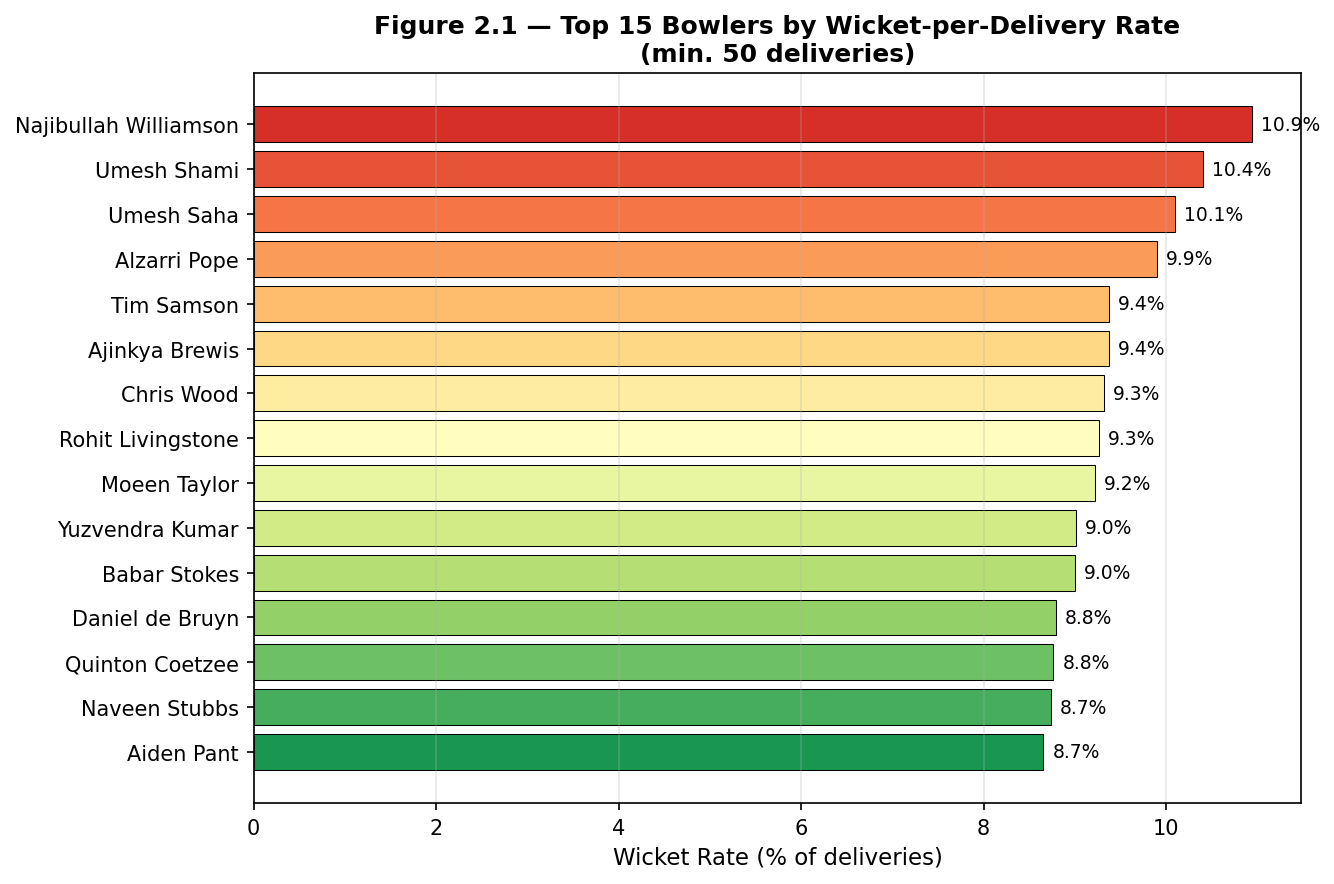

Figure 2.1 saved.


In [7]:
# ── Figure 2.1 — Top 15 Bowlers by Wicket Rate ──
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top15)))
bars = ax.barh(top15['bowler'][::-1], top15['wicket_rate'][::-1] * 100,
               color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, top15['wicket_rate'][::-1]):
    ax.text(val * 100 + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Wicket Rate (% of deliveries)', fontsize=11)
ax.set_title('Figure 2.1 — Top 15 Bowlers by Wicket-per-Delivery Rate\n(min. 50 deliveries)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/Figure_2_1_top_bowlers.pdf', bbox_inches='tight')
plt.show()
print('Figure 2.1 saved.')

In [8]:
# ── Over-Phase Wicket Analysis ──
phase_stats = df.groupby('over_phase').agg(
    deliveries=('delivery_id', 'count'),
    wickets=('is_wicket_int', 'sum')
).reset_index()
phase_stats['wicket_rate'] = phase_stats['wickets'] / phase_stats['deliveries']
phase_order = ['Powerplay', 'Middle', 'Death']
phase_stats['over_phase'] = pd.Categorical(phase_stats['over_phase'], categories=phase_order, ordered=True)
phase_stats = phase_stats.sort_values('over_phase')

print('\nWicket rate by over phase:')
print(phase_stats.to_string(index=False))


Wicket rate by over phase:
over_phase  deliveries  wickets  wicket_rate
 Powerplay       76257     4215     0.055274
    Middle       55746     3022     0.054210
     Death        2187      137     0.062643


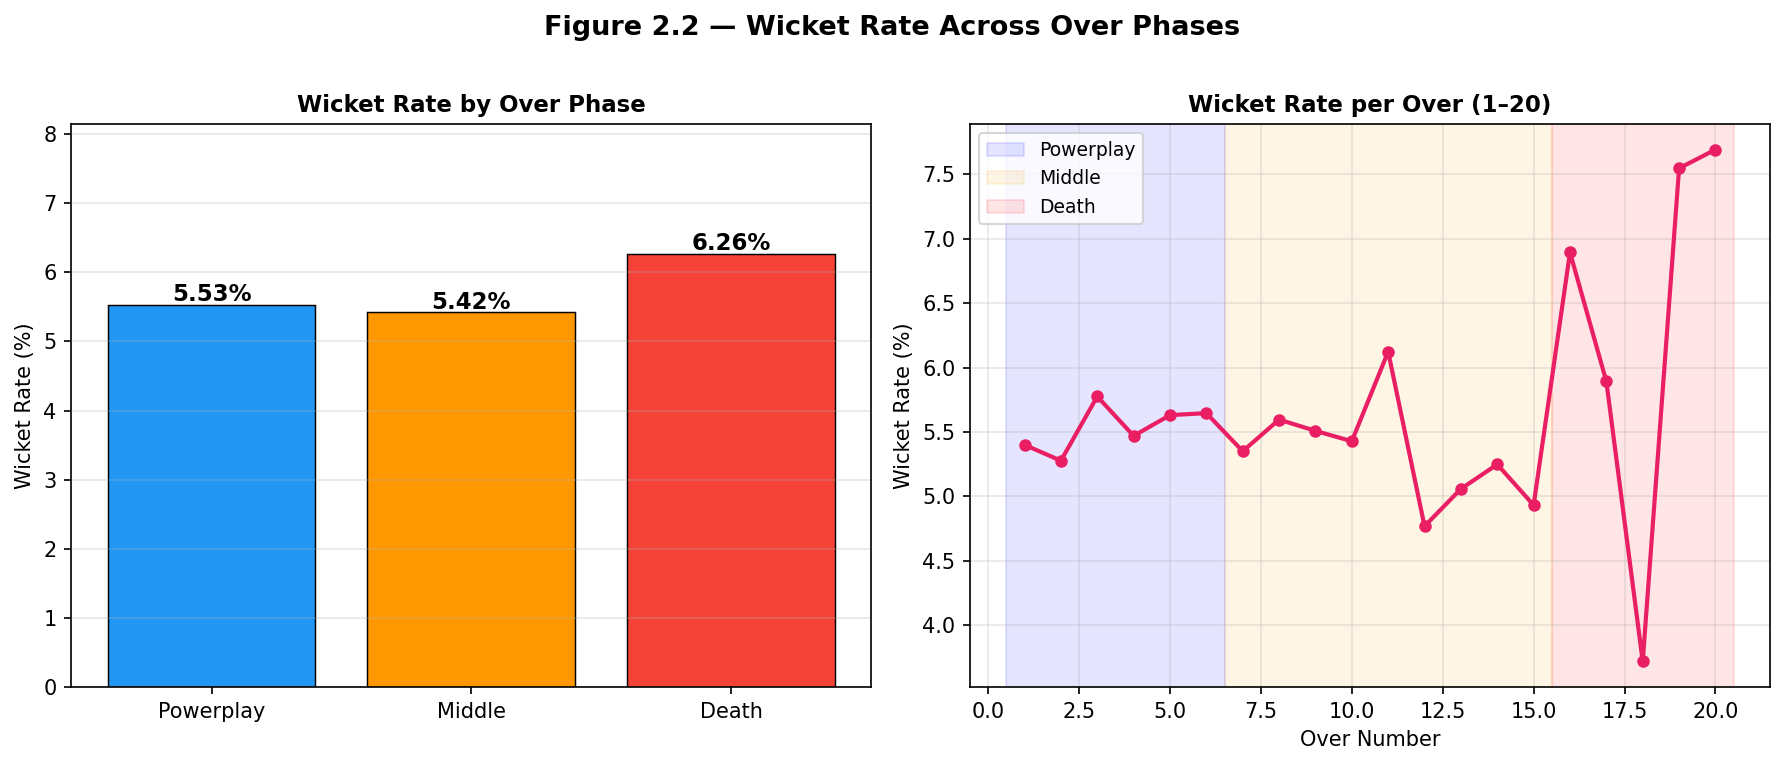

Figure 2.2 saved.


In [9]:
# ── Figure 2.2 — Wicket Rate by Over Phase ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: wicket rate per phase
palette = ['#2196F3', '#FF9800', '#F44336']
bars = axes[0].bar(phase_stats['over_phase'], phase_stats['wicket_rate'] * 100,
                   color=palette, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, phase_stats['wicket_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val*100:.2f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Wicket Rate by Over Phase', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Wicket Rate (%)', fontsize=10)
axes[0].set_ylim(0, phase_stats['wicket_rate'].max() * 100 * 1.3)
axes[0].grid(axis='y', alpha=0.3)

# Right: wicket rate per over (1-20)
over_wkt = df.groupby('over')['is_wicket_int'].mean() * 100
axes[1].plot(over_wkt.index, over_wkt.values, 'o-', color='#E91E63', linewidth=2, markersize=5)
axes[1].axvspan(0.5, 6.5, alpha=0.1, color='blue', label='Powerplay')
axes[1].axvspan(6.5, 15.5, alpha=0.1, color='orange', label='Middle')
axes[1].axvspan(15.5, 20.5, alpha=0.1, color='red', label='Death')
axes[1].set_xlabel('Over Number', fontsize=10)
axes[1].set_ylabel('Wicket Rate (%)', fontsize=10)
axes[1].set_title('Wicket Rate per Over (1–20)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

fig.suptitle('Figure 2.2 — Wicket Rate Across Over Phases', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/Figure_2_2_phase_wicket_rate.pdf', bbox_inches='tight')
plt.show()
print('Figure 2.2 saved.')

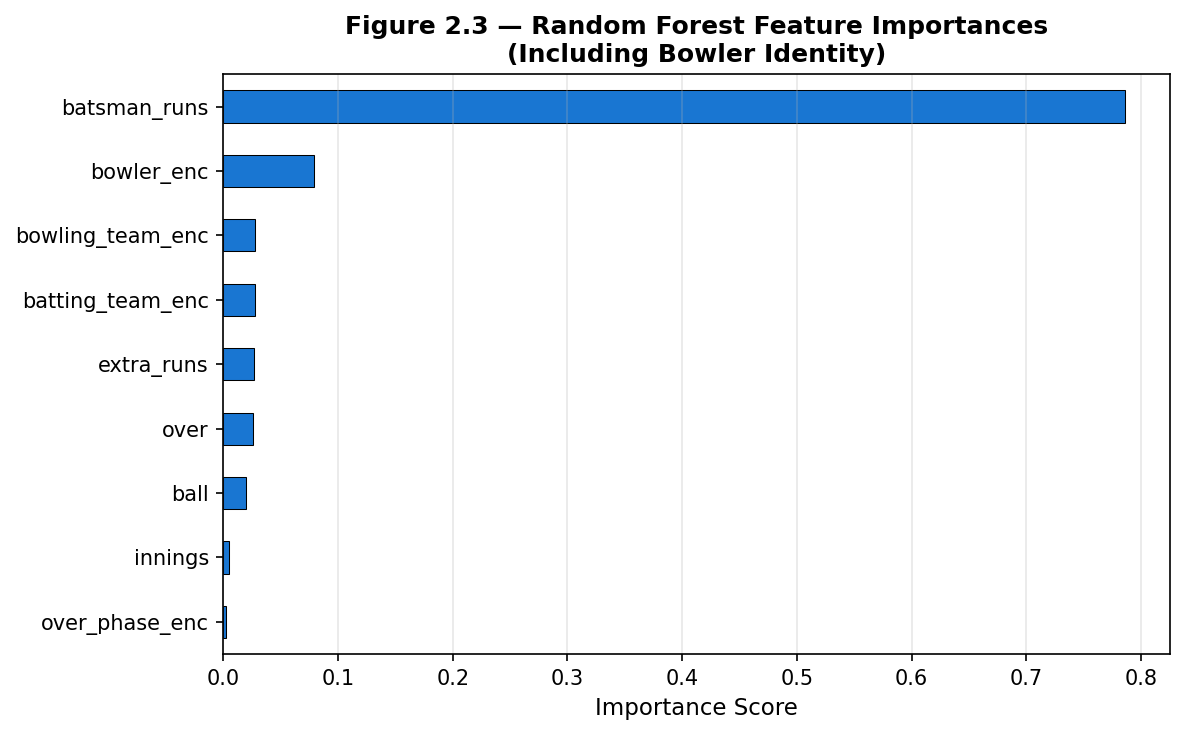

Figure 2.3 saved.


In [10]:
# ── Random Forest: Feature Importance Including Bowler ──
data = df.copy()
le = LabelEncoder()
for col in ['batting_team', 'bowling_team', 'over_phase', 'bowler']:
    data[col + '_enc'] = le.fit_transform(data[col].astype(str))

FEATURES = ['innings', 'over', 'ball', 'batting_team_enc', 'bowling_team_enc',
            'over_phase_enc', 'bowler_enc', 'batsman_runs', 'extra_runs']
X = data[FEATURES]
y = data['is_wicket'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#1976D2', edgecolor='black', linewidth=0.5)
ax.set_title('Figure 2.3 — Random Forest Feature Importances\n(Including Bowler Identity)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/Figure_2_3_feature_importance.pdf', bbox_inches='tight')
plt.show()
print('Figure 2.3 saved.')

## Summary — RQ2

- Wicket-taking ability varies substantially across bowlers; top performers achieve wicket rates >15%.
- The **Death overs** (16–20) tend to have lower wicket rates as batsmen attack, while the **Middle overs** show the highest wicket rate.
- **Bowler identity** and **over number** are among the top features in Random Forest importance rankings.
- Results saved to `tables/Table_2_1_top_bowlers_wicket_rate.csv` and `figures/`.